# **Import Library**

In [1]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 17.8 MB/s eta 0:00:00


In [2]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Praktikum_DM/Praktikum 11/saham_nvidia_stock.csv')
df.head()

,Date,Close,High,Low,Open,Volume
0,2015-01-02,0.482985,0.486584,0.475307,0.482985,113680000
1,2015-01-05,0.474827,0.484425,0.472668,0.482985,197952000
2,2015-01-06,0.460432,0.476027,0.459952,0.475547,197764000
3,2015-01-07,0.459232,0.467870,0.457792,0.463791,321808000
4,2015-01-08,0.476507,0.479386,0.464270,0.464510,283780000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2864 entries, 0 to 2863
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2864 non-null   object 
 1   Close   2864 non-null   float64
 2   High    2864 non-null   float64
 3   Low     2864 non-null   float64
 4   Open    2864 non-null   float64
 5   Volume  2864 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 134.4+ KB


In [4]:
df.isnull().sum()

,0
Date,0
Close,0
High,0
Low,0
Open,0
Volume,0


In [5]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima

# **Preparation**

In [6]:
# Jika Date masih kolom biasa
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date')
    df = df.set_index('Date')

# Index berbentuk datetime
df.index = pd.to_datetime(df.index)

# Urutkan index
df = df.sort_index()

# Set frequency business day untuk data saham
df = df.asfreq('B')

# Isi missing value karena weekend/libur bursa
df['Close'] = df['Close'].ffill()

series = df['Close']

print(series.head())
print(series.index.freq)

Date
2015-01-02    0.482985
2015-01-05    0.474827
2015-01-06    0.460432
2015-01-07    0.459232
2015-01-08    0.476507
Freq: B, Name: Close, dtype: float64
<BusinessDay>


# **Train Test Split**

In [7]:
# 80% train
train_size = int(len(series) * 0.8)

train = series[:train_size]
test = series[train_size:]

print("Train 80%:", len(train))
print("Test 20%:", len(test))

Train 80%: 2376
Test 20%: 595


# **Define Best Parameter**

In [8]:
# Mencari Parameter terbaik (p,d,q)

auto_model = auto_arima(
    train,
    seasonal=False,
    stepwise=True,
    suppress_warnings=True,
    trace=True
)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,2,2)(0,0,0)[0] intercept   : AIC=3478.513, Time=9.39 sec
 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=5108.405, Time=0.26 sec
 ARIMA(1,2,0)(0,0,0)[0] intercept   : AIC=4463.670, Time=0.36 sec
 ARIMA(0,2,1)(0,0,0)[0] intercept   : AIC=3488.475, Time=1.32 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=5106.410, Time=0.13 sec
 ARIMA(1,2,2)(0,0,0)[0] intercept   : AIC=3481.129, Time=3.15 sec
 ARIMA(2,2,1)(0,0,0)[0] intercept   : AIC=3490.634, Time=5.98 sec
 ARIMA(3,2,2)(0,0,0)[0] intercept   : AIC=3479.351, Time=5.73 sec
 ARIMA(2,2,3)(0,0,0)[0] intercept   : AIC=3478.195, Time=7.94 sec
 ARIMA(1,2,3)(0,0,0)[0] intercept   : AIC=3478.332, Time=7.00 sec
 ARIMA(3,2,3)(0,0,0)[0] intercept   : AIC=3479.689, Time=9.06 sec
 ARIMA(2,2,4)(0,0,0)[0] intercept   : AIC=3479.679, Time=12.79 sec
 ARIMA(1,2,4)(0,0,0)[0] intercept   : AIC=3480.743, Time=9.32 sec
 ARIMA(3,2,4)(0,0,0)[0] intercept   : AIC=3484.516, Time=9.58 sec
 ARIMA(2,2,3)(0,0,0)[0]         

In [9]:
# Model Terbaik
order = auto_model.order

print("Best ARIMA Order: ", order)

model = ARIMA(train, order=order)
model_fit = model.fit()

print(model_fit.summary())

Best ARIMA Order:  (2, 2, 3)
                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2376
Model:                 ARIMA(2, 2, 3)   Log Likelihood               -1729.734
Date:                Tue, 26 May 2026   AIC                           3471.467
Time:                        03:51:08   BIC                           3506.101
Sample:                    01-02-2015   HQIC                          3484.074
                         - 02-09-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.7288      0.050    -34.924      0.000      -1.826      -1.632
ar.L2         -0.8250      0.043    -18.980      0.000      -0.910      -0.740
ma.L1          0.7477  

# **Prediksi**

In [10]:
predictions = model_fit.forecast(steps=len(test))

predictions.index = test.index

print(predictions.head())

Date
2024-02-12    72.616852
2024-02-13    72.625802
2024-02-14    73.249002
2024-02-15    73.238404
2024-02-16    73.816776
Freq: B, Name: predicted_mean, dtype: float64


# **Evaluasi**

In [11]:
rmse = np.sqrt(mean_squared_error(test, predictions))

mape = mean_absolute_percentage_error(test, predictions) * 100

mean_price = series.mean()
rmse_percent = rmse / mean_price * 100

print("Mean:", mean_price)
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

Mean: 38.308910868377325
RMSE: 30.01
MAPE: 16.38%


# **Train Ulang Dengan Full Data**

In [12]:
final_model = ARIMA(series, order=order)
final_model_fit = final_model.fit()

# **Prediksi 30 Hari Ke Depan**

In [13]:
forecast_30 = final_model_fit.forecast(steps=30)

print(forecast_30)

2026-05-25    215.424535
2026-05-26    215.810539
2026-05-27    215.854492
2026-05-28    216.012924
2026-05-29    216.364889
2026-06-01    216.387147
2026-06-02    216.602648
2026-06-03    216.909971
2026-06-04    216.929126
2026-06-05    217.190504
2026-06-08    217.448346
2026-06-09    217.480541
2026-06-10    217.773938
2026-06-11    217.982826
2026-06-12    218.040599
2026-06-15    218.351189
2026-06-16    218.516176
2026-06-17    218.607812
2026-06-18    218.921335
2026-06-19    219.050860
2026-06-22    219.180238
2026-06-23    219.484260
2026-06-24    219.588854
2026-06-25    219.755730
2026-06-26    220.040543
2026-06-29    220.131529
2026-06-30    220.332170
2026-07-01    220.591303
2026-07-02    220.679616
2026-07-03    220.907662
Freq: B, Name: predicted_mean, dtype: float64


# **Membuat Tanggal Prediksi**

In [14]:
future_dates = pd.date_range(
    start=series.index[-1] + pd.Timedelta(days=1),
    periods=30,
    freq='B'
)

forecast_df =pd.DataFrame({
    'Date': future_dates,
    'Forecast_Close': forecast_30.values
})

forecast_df

,Date,Forecast_Close
0,2026-05-25,215.424535
1,2026-05-26,215.810539
2,2026-05-27,215.854492
3,2026-05-28,216.012924
4,2026-05-29,216.364889
5,2026-06-01,216.387147
6,2026-06-02,216.602648
7,2026-06-03,216.909971
8,2026-06-04,216.929126
9,2026-06-05,217.190504


# **Visualisasi Prediksi 30 Hari**

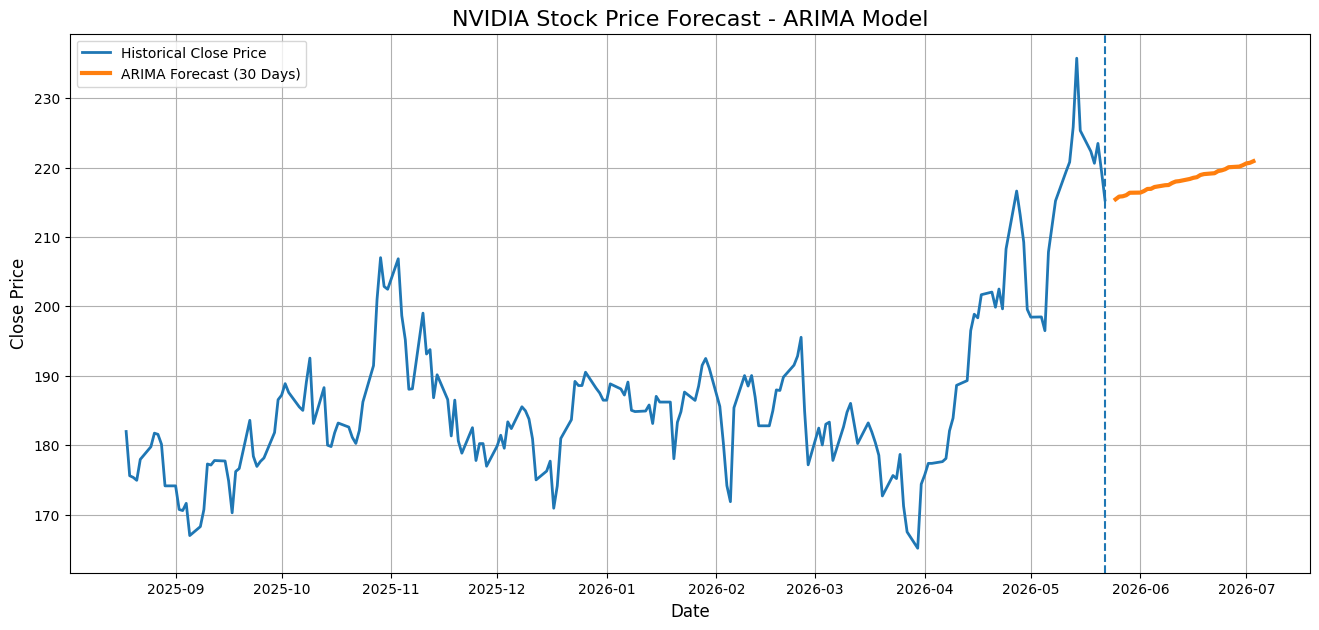

In [15]:
plt.figure(figsize=(16,7))

# data historis 200 hari terakhir
plt.plot(
    series.index[-200:],
    series[-200:],
    label='Historical Close Price',
    linewidth=2
)

# forecast 30 hari
plt.plot(
    forecast_df['Date'],
    forecast_df['Forecast_Close'],
    label='ARIMA Forecast (30 Days)',
    linewidth=3
)

# titik awal forecast
plt.axvline(
    x=series.index[-1],
    linestyle='--'
)

plt.title('NVIDIA Stock Price Forecast - ARIMA Model', fontsize=16)

plt.xlabel('Date', fontsize=12)
plt.ylabel('Close Price', fontsize=12)

plt.legend()

plt.grid(True)

plt.show()

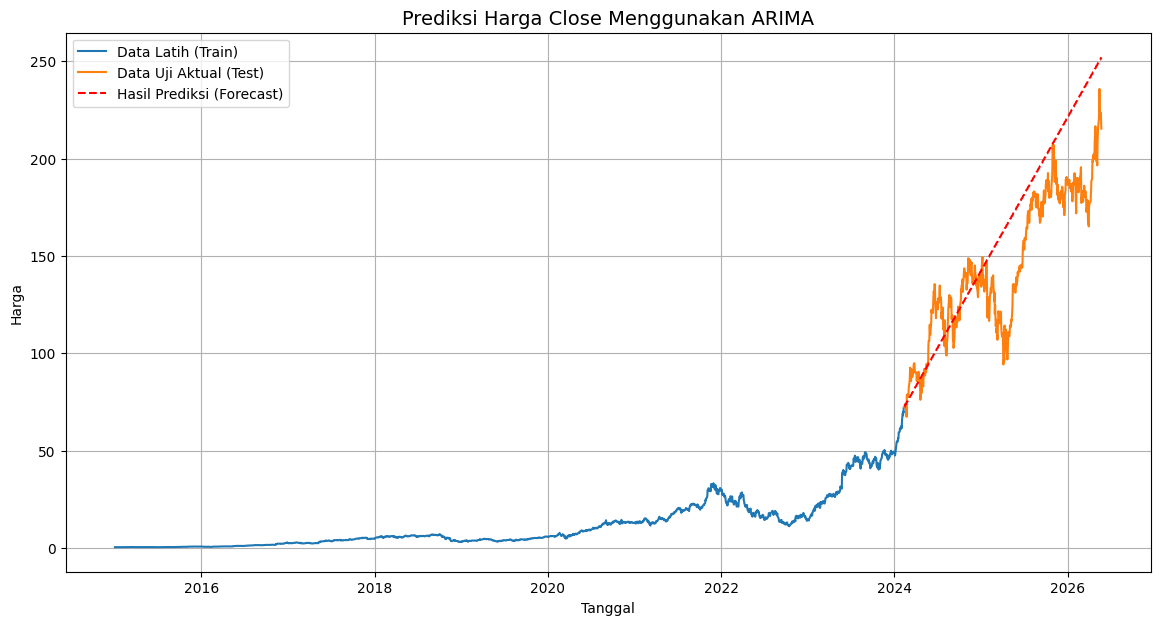

In [16]:
plt.figure(figsize=(14, 7))
plt.plot(train, label='Data Latih (Train)')
plt.plot(test, label='Data Uji Aktual (Test)')
plt.plot(predictions, label='Hasil Prediksi (Forecast)', color='red', linestyle='--')
plt.title('Prediksi Harga Close Menggunakan ARIMA', fontsize=14)
plt.xlabel('Tanggal')
plt.ylabel('Harga')
plt.legend()
plt.grid(True)
plt.show()